In [ ]:
import pandas as pd

df = pd.read_csv("city_day.csv")
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


total of 16 features in the dataset

In [ ]:
print(df.columns)


Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')


In [ ]:
cols_needed = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 'AQI']
df = df[cols_needed]


finding total null values

In [ ]:
df.isnull().sum()

,0
PM2.5,4598
PM10,11140
NO2,3585
CO,2059
SO2,3854
O3,4022
AQI,4681


In [ ]:
df.shape

(29531, 7)

drop those who dont have aqi

In [ ]:
df = df.dropna(subset=['AQI'])
print(df.shape)

(24850, 7)


important features

In [ ]:
features = ['PM2.5','PM10','NO2','CO','SO2','O3']
df[features] = df[features].fillna(df[features].median())


null values cleaned

In [ ]:
df.isnull().sum()


,0
PM2.5,0
PM10,0
NO2,0
CO,0
SO2,0
O3,0
AQI,0


imput variable

In [ ]:
X = df[['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']]

In [ ]:
output variable

In [ ]:
y = df['AQI']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

model fit= learning   model predict will generate predictions

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

r2 = r2_score(y_test, y_pred)

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAPE :", mape, "%")
print("R²   :", r2)

MAE  : 31.13105183354941
MSE  : 3544.059169995341
RMSE : 59.53200122619213
MAPE : 21.35799932831193 %
R²   : 0.8064521285443192


decent values

In [ ]:
new_data = [[80, 120, 40, 1.2, 10, 30]]  # pollutant values
predicted_aqi = model.predict(new_data)

print(predicted_aqi)

[168.84943426]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


now improving using random forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [ ]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

rf_mape = np.mean(np.abs((y_test - rf_pred) / (y_test + 1e-10))) * 100

print("Random Forest Performance:")
print("MAE  :", rf_mae)
print("RMSE :", rf_rmse)
print("MAPE :", rf_mape, "%")
print("R²   :", rf_r2)

Random Forest Performance:
MAE  : 21.98365489575695
RMSE : 42.04770562883484
MAPE : 14.726577583339534 %
R²   : 0.9034456061706183


improved values

In [ ]:
new_data_df = pd.DataFrame(
    [[80, 120, 40, 1.2, 10, 30]],
    columns=['PM2.5','PM10','NO2','CO','SO2','O3']
)

rf_new_pred = rf_model.predict(new_data_df)
print("Predicted AQI (RF):", rf_new_pred[0])

Predicted AQI (RF): 173.87


gave input data-> model predicted output aqi

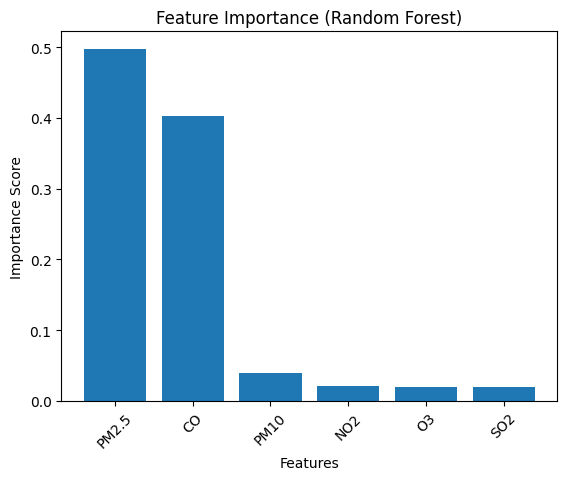

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


importances = rf_model.feature_importances_
feature_names = X.columns


fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)


plt.figure()
plt.bar(fi_df["Feature"], fi_df["Importance"])
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()

graph showing impact of different pollutants on aqi value